Problem Statement 
Write a Qiskit function that takes a 2n dimensional vector, φ∈C2n
, such that ‖ψ‖2 =1, and outputs a circuit,
U , such that

U |0〉n =
2n −1∑
x=0
ψx |x〉n

The construction may use any number of ancillas, arbitrary 1-qubit gates and multi-controlled RZ gates, (the
number of controlled may be arbitrarily large). No classical bit and measurements allowed.
Expectations:
• Documentation.
• Working Qiskit code for all n and demo for n =3.

For 2 qubits:


For 3 qubits:

Recursion for general state preparation

In [7]:
#Imports

from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, Parameter
from qiskit.quantum_info import Statevector, Operator, state_fidelity

import numpy as np

In [ ]:
# Calculating angles for the Ry and Rz rotations to prepare the amplitudes and phases respectively
# Every i^th step, split the amplitude vector into 2^i blocks, calculate one angle for each block 
# In the m^th block of the i^th iteration, the angle is calculates as 
# theta_amps[i,m] = 2 * arccos(norm of the first half of the block/norm of the full block)
# theta_phases[i,m] = mean of the second half - mean of the first half

# The loops i go from 0 to n-1 for a total of n iterations for n qubits, and m goes from 1 to 2^i.

def find_thetas(amps, phases, n):
    """
    Calculate the angles for the Ry rotations to prepare the amplitudes and the Rz rotations to prepare the phases.
    Args:
        amps (np.ndarray): 2^n dimensional vector of (real, positive) amplitudes.
        phases (np.ndarray): 2^n dimensional vector of phases in radians.
        n (int): Number of qubits.
    Returns:
        thetas_amps (np.ndarray): 2D array of angles for the Ry rotations
        thetas_phases (np.ndarray): 2D array of angles for the Rz rotations
    """
    thetas_amps = np.zeros((n, 2**(n-1))) # store the angles for each block in a 2D array, the first index is the iteration, the second is the block number
    thetas_phases = np.zeros((n, 2**(n-1)))
    for i in range(n):

        blocks_amps = np.split(amps, 2**i) # split the amplitude vector into 2^i blocks
        blocks_phases = np.split(phases, 2**i) # split the phase vector into 2^i blocks

        for m, block in enumerate(blocks_amps):
            first_half = block[:len(block)//2]            
            if np.linalg.norm(block) != 0:
                thetas_amps[i][m] = 2 * np.arccos(np.linalg.norm(first_half)/np.linalg.norm(block))
            else: 
                thetas_amps[i][m] = 0

        for m, block in enumerate(blocks_phases):
            first_half = block[:len(block)//2]
            second_half = block[len(block)//2:]
            thetas_phases[i][m] = np.mean(second_half) - np.mean(first_half)
            
    return thetas_amps, thetas_phases    

In [9]:
# Construct the quantum circuit
# with theta[i][m] we need to construct a multiplexed R_y rotation(or R_z, using R_y from here throughout, exactly same 
# structure for the R_z rotations to implement phases, which is why we are abstracting this out as a function) 

# On the n-1+i^th qubit (starting at the bottommost/leftmost qubit and working our way up the circuit), controlled by i qubits.
# Note that we have i+1 angles for the i^th R_y rotation, so for i=0, on the bottommost qubit, we have 1 angle, 
# we apply a simple R_y rotation here, 0 control qubits. For i = 1, we have 2 angles, we apply multiplexed Ry on 
# the n-2^th qubit, controlled on the n-1^th qubit, each angle corresponsing to the control qubit being 0 or 1 respectivly. 
# FOr i=2, we have 4 angles, we apply multiplexed Ry on the n-3 qubit, controlled on the n-2 and n-1 qubits, 
# each angle corresponding to the control qubits being 00, 01, 10, 11 respectively.

def multiplexed_rotations_for_state_prep(n, thetas, gate, quantum_register, state_prep_circ):
    """
    Constructs a quantum circuit for state preparation using multiplexed rotations.

    Args:
        n (int): Number of qubits.
        thetas (list): List of angles for the rotations.
        gate (Gate): The rotation gate to be used (e.g., RYGate, RZGate).
        quantum_register (QuantumRegister): The quantum register to apply the rotations on.
        state_prep_circ (QuantumCircuit): The quantum circuit to append the rotations to.
    Returns:
        QuantumCircuit: The quantum circuit with the multiplexed rotations applied.
    """
 
    for i in range(n):

        if i == 0:
            state_prep_circ.append(gate(thetas[0][0]), [quantum_register[n-1]]) # apply the first Ry rotation on the bottommost qubit, with no control qubits
            state_prep_circ.barrier()

        else:
            num_control_qubits = i
            control_qubits = quantum_register[n-1 : n-1-i : -1] 
            control_bitstrings = [f'{m:0{num_control_qubits}b}' for m in range(2**num_control_qubits)] #enumerate control qubit bitstrings 
            
            # The multiplexed Ry requires choosing the rotation angle depending on the control bitstring. We do this 
            # by looping over the 2^i-1 possible (angle, bitstring) pairs at every i^th step, and
            # for the m^th angle corresponding to the m^th control bitstring, we turn the multiplexed Ry as a simpler
            # multicontrolled Ry using an x bitmask on the control qubits.  
            for m in range(2**num_control_qubits):
                zero_qubits = []
                for b, q in zip(control_bitstrings[m], control_qubits):
                    if b=='0':
                        zero_qubits += [q] 
                
                if zero_qubits:
                    #apply x gate in stat_prep_circ if the control bit above is zero. 
                    state_prep_circ.x(zero_qubits)

                #apply the multiplexed Ry rotation on the target qubit, controlled by the control qubits, with the angles calculated above.
                # append takes qubit arguments as a single list, target, then controls
            
                state_prep_circ.append(gate(thetas[i][m]).control(i),control_qubits+[quantum_register[n-1-i]])

                if zero_qubits:
                    #apply x gate in stat_prep_circ to the same qubits as above to flip them back
                    state_prep_circ.x(zero_qubits)

                state_prep_circ.barrier()
                
    #return state_prep_circ


In [10]:
from qiskit.circuit.library.standard_gates import RYGate, RZGate

# FOR DEMO, set number of qubits, code works for general n
n = 3

# Input an n qubit state as a 2^n dimensional vector of amplitudes, assuming little-endian convention
input_psi = np.random.randn(2**n) #+ 1j* np.random.randn(2**n)

# OR input amplitude vector directly
#input_psi = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])

if np.linalg.norm(input_psi) != 1:
    input_psi = input_psi/np.linalg.norm(input_psi) # normalize 

# Note that the default qiskit convention is little endian. Which is what we use throughout this project
# So for example, for two qubits, the ordering of amplitudes is 00, 01, 10, 11
# The first qubit, q0, the rightmost one, which is the topmost in a circuit, is the least significant and flips first
target_initial_state = Statevector(input_psi) 

n = int(np.log2(len(input_psi))) # number of qubits 
print(n)

# Split into real amplitudes and phases, these are implemented separately 
amps = np.abs(input_psi) #2^n dimensional vector of (real, positive) amplitudes
phases = np.angle(input_psi) #2^n dimensional vector of phases in radians

thetas_amps, thetas_phases = find_thetas(amps, phases, n)

# Construct the quantum circuit
quantum_register = QuantumRegister(size=n, name="qreg")

state_prep_circ = QuantumCircuit(quantum_register, name="Quantum State Preparation")

# Apply multiplexed rotations for amplitude preparation, returns circuit after amplitude prep
multiplexed_rotations_for_state_prep(n, thetas_amps, RYGate, quantum_register, state_prep_circ)   

# Apply multiplexed rotations for phase preparation, returns final circuit after phase prep
multiplexed_rotations_for_state_prep(n, thetas_phases, RZGate, quantum_register, state_prep_circ)

#Compare the final state of the circuit with the target state
prepared_state = Statevector(state_prep_circ)
target_initial_state = Statevector(input_psi)

# Calculate the fidelity between the prepared state and the target state
# (fidelity ignores the global phase)
fidelity = state_fidelity(prepared_state, target_initial_state) 
print(f"Fidelity between the prepared state and the target state: {fidelity}")

3
Fidelity between the prepared state and the target state: 0.030848734707847214


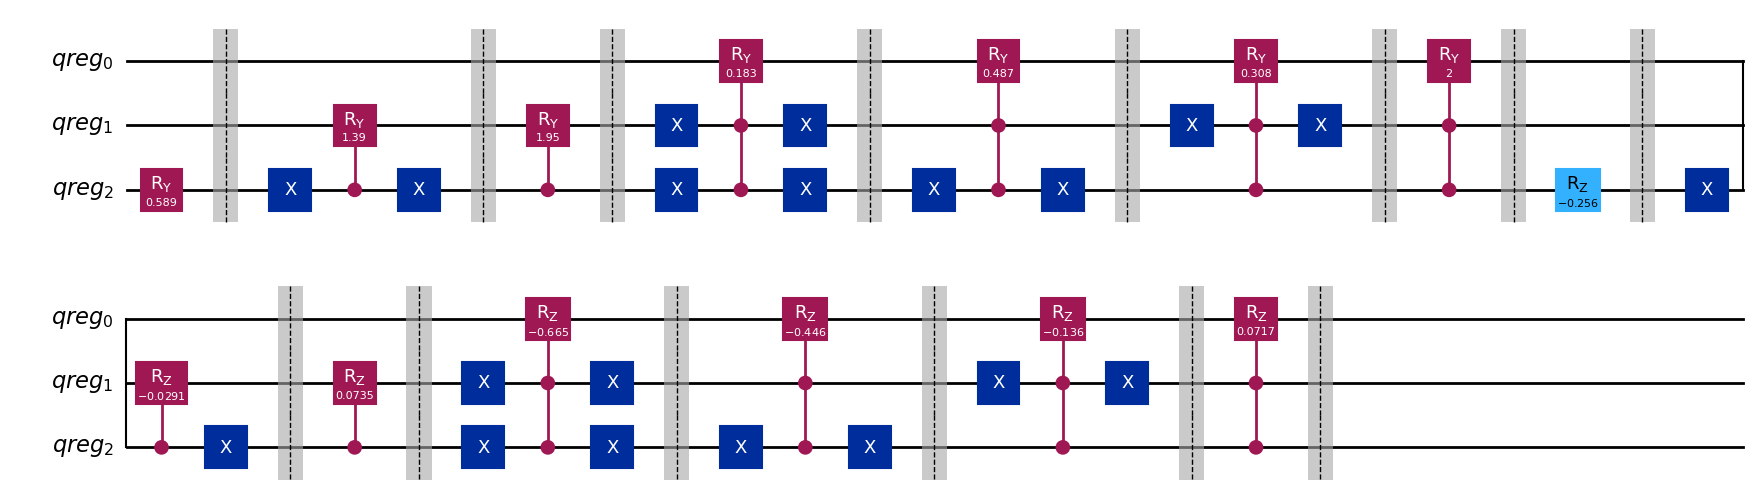

In [11]:
# Draw the full quantum circuit
state_prep_circ.draw(output='mpl')

In [ ]:
# Calculating angles for the Rz rotations to prepare the phases
# Every i^th step, split the phase vector into 2^i blocks, calculate one angle for each block 
# In the m^th block of the i^th iteration, the angle is calculates as 
# theta_i,m = mean (block1) - mean (block2)

# The loops i go from 0 to n-1 for a total of n iterations for n qubits, and m goes from 1 to 2^i.

thetas_phases = np.zeros((n, 2**(n-1))) # store the angles for each block in a 2D array, the first index is the iteration, the second is the block number
blocks =[]
for i in range(n):
    blocks = np.split(phases, 2**i) # split the amplitude vector into 2^i blocks
    for m, block in enumerate(blocks):
        first_half = block[:len(block)//2]
        second_half = block[len(block)//2:]
        thetas_phases[i][m] = np.mean(second_half) - np.mean(first_half)
print(thetas_phases)     

In [ ]:
# Write the quantum circuit
# with theta[i][m] we need to construct a multiplexed R_y rotation on the n-1+i^th qubit 
# (starting at the bottommost/leftmost qubit and working our way up the circuit), controlled by i qubits.
# Note that we have i+1 angles for the i^th R_y rotation, so for i=0, on the bottommost qubit, we have 1 angle, 
# we apply a simple R_y rotation here, 0 control qubits. For i = 1, we have 2 angles, we apply multiplexed Ry on 
# the n-2^th qubit, controlled on the n-1^th qubit, each angle corresponsing to the control qubit being 0 or 1 respectivly. 
# FOr i=2, we have 4 angles, we apply multiplexed Ry on the n-3 qubit, controlled on the n-2 and n-1 qubits, 
# each angle corresponding to the control qubits being 00, 01, 10, 11 respectively.

# Here we write the general circuit for n qubits, with the angles calculated above. 

from qiskit.circuit.library.standard_gates import RZGate

for i in range(n):

    if i == 0:
        state_prep_circ.rz(thetas_phases[0][0], quantum_register[n-1]) # apply the first Ry rotation on the bottommost qubit, with no control qubits
        state_prep_circ.barrier()

    else:
        num_control_qubits = i
        control_qubits = quantum_register[n-1 : n-1-i : -1] 
        control_bitstrings = [f'{m:0{num_control_qubits}b}' for m in range(2**num_control_qubits)] #enumerate control qubit bitstrings 
        
        # The multiplexed Ry requires choosing the rotation angle depending on the control bitstring. We do this 
        # by looping over the 2^i-1 possible (angle, bitstring) pairs at every i^th step, and
        # for the m^th angle corresponding to the m^th control bitstring, we turn the multiplexed Ry as a simpler
        # multicontrolled Ry using an x bitmask on the control qubits.  
        for m in range(2**num_control_qubits):
            zero_qubits = []
            for b, q in zip(control_bitstrings[m], control_qubits):
                if b=='0':
                    zero_qubits += [q] 
            
            if zero_qubits:
                #apply x gate in stat_prep_circ if the control bit above is zero. 
                state_prep_circ.x(zero_qubits)

            #apply the multiplexed Ry rotation on the target qubit, controlled by the control qubits, with the angles calculated above.
            # append takes qubit arguments as a single list, target, then controls
          
            state_prep_circ.append(RZGate(thetas_phases[i][m]).control(i),control_qubits+[quantum_register[n-1-i]])

            if zero_qubits:
                #apply x gate in stat_prep_circ to the same qubits as above to flip them back
                state_prep_circ.x(zero_qubits)

            state_prep_circ.barrier()
            
state_prep_circ.draw(output="mpl")


In [ ]:
# Check the circuit output with the target initial state 

prepared_state = Statevector(state_prep_circ)
print(np.linalg.norm(prepared_state - target_initial_state))
fidelity = state_fidelity(Statevector(state_prep_circ), Statevector(input_psi))
print(fidelity)

In [ ]:
# For demo, set number of qubits, code works for general n
n = 3

# Input an n qubit state as a 2^n dimensional vector of amplitudes, assuming little-endian convention
input_psi = np.random.randn(2**n) + 1j* np.random.randn(2**n)

# OR input amplitude vector directly
#input_psi = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])

if np.linalg.norm(input_psi) != 1:
    input_psi = input_psi/np.linalg.norm(input_psi) # normalize 

# Note that the default qiskit convention is little endian. Which is what we use throughout this project
# So for example, for two qubits, the ordering of amplitudes is 00, 01, 10, 11
# The first qubit, q0, the rightmost one, which is the topmost in a circuit, is the least significant and flips first
target_initial_state = Statevector(input_psi) 

n = int(np.log2(len(input_psi))) # number of qubits 
print(n)

# Split into real amplitudes and phases, these are implemented separately 
amps = np.abs(input_psi) #2^n dimensional vector of (real, positive) amplitudes
phases = np.angle(input_psi) #2^n dimensional vector of phases in radians